<a href="https://colab.research.google.com/github/bubai-jkc/leaf-disease_unet_resnet50_resnet101/blob/main/8008resnet50_leaf_disease_focal_loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:


# --- 1. SETUP AND DATA DOWNLOAD ---
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!kaggle datasets download -d fakhrealam9537/leaf-disease-segmentation-dataset

import zipfile
import os
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from tqdm import tqdm
from google.colab import files

# Extract Dataset
zip_ref = zipfile.ZipFile('/content/leaf-disease-segmentation-dataset.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

# --- 2. CONFIGURATION ---
DATASET_PATH = "/content/aug_data/aug_data"
IMG_SIZE = (256, 256)
BATCH_SIZE = 8
LEARNING_RATE = 1e-5
NUM_EPOCHS = 120
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 3. FOCAL LOSS IMPLEMENTATION ---
# This focuses the model on "hard" pixels at the edges of disease spots
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1 - pt)**self.gamma * BCE_loss

        if self.reduction == 'mean':
            return torch.mean(F_loss)
        else:
            return torch.sum(F_loss)

# --- 4. DATASET CLASS ---
class LeafDiseaseDataset(Dataset):
    def __init__(self, root_dir, img_size=IMG_SIZE, augment=False):
        self.images_dir = os.path.join(root_dir, "images")
        self.masks_dir  = os.path.join(root_dir, "masks")
        self.img_size = img_size
        self.image_files = sorted(os.listdir(self.images_dir))
        self.augment = augment
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path  = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.masks_dir, img_name.replace(".jpg", ".png"))

        image = Image.open(img_path).convert("RGB")
        mask  = Image.open(mask_path).convert("L")

        image = image.resize(self.img_size)
        mask  = mask.resize(self.img_size, resample=Image.NEAREST)

        if self.augment:
            if np.random.random() > 0.5:
                image = transforms.functional.hflip(image); mask = transforms.functional.hflip(mask)
            if np.random.random() > 0.5:
                image = transforms.functional.vflip(image); mask = transforms.functional.vflip(mask)
            angle = np.random.randint(-30, 30)
            image = transforms.functional.rotate(image, angle); mask = transforms.functional.rotate(mask, angle)

        image = transforms.ToTensor()(image)
        image = self.normalize(image)
        mask = transforms.ToTensor()(mask)
        mask = (mask > 0).float()
        return image, mask

# Split Logic
full_dataset = LeafDiseaseDataset(DATASET_PATH, augment=True)
train_size = int(0.75 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
val_dataset.dataset.augment = False

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- 5. MODEL ARCHITECTURE (RESNET50-UNET) ---
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.2),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch // 2 + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x); x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class ResNet50UNet(nn.Module):
    def __init__(self, n_classes=1):
        super().__init__()
        base_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        base_layers = list(base_model.children())
        self.init_conv = nn.Sequential(*base_layers[:3])
        self.pool = base_layers[3]
        self.layer1 = base_layers[4]; self.layer2 = base_layers[5]
        self.layer3 = base_layers[6]; self.layer4 = base_layers[7]
        self.up1 = DecoderBlock(2048, 1024, 512); self.up2 = DecoderBlock(512, 512, 256)
        self.up3 = DecoderBlock(256, 256, 128); self.up4 = DecoderBlock(128, 64, 64)
        self.final_up = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, x):
        x0 = self.init_conv(x); x1 = self.pool(x0); x1 = self.layer1(x1)
        x2 = self.layer2(x1); x3 = self.layer3(x2); x4 = self.layer4(x3)
        d1 = self.up1(x4, x3); d2 = self.up2(d1, x2)
        d3 = self.up3(d2, x1); d4 = self.up4(d3, x0)
        return self.final_conv(self.final_up(d4))

# --- 6. UTILITIES ---
def mean_iou(preds, masks, eps=1e-6):
    preds = (torch.sigmoid(preds) > 0.5).float()
    intersection = (preds * masks).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - intersection
    return ((intersection + eps) / (union + eps)).mean()

model = ResNet50UNet().to(DEVICE)
criterion = FocalLoss(alpha=0.25, gamma=1)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

train_losses, val_losses = [], []
train_ious, val_ious = [], []
best_iou = 0.0

# --- 7. TRAINING LOOP ---

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, running_iou = 0.0, 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)

    for images, masks in pbar:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        outputs = model(images); loss = criterion(outputs, masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running_loss += loss.item() * images.size(0)
        running_iou  += mean_iou(outputs, masks).item() * images.size(0)

    avg_train_loss = running_loss / len(train_dataset)
    avg_train_iou = running_iou / len(train_dataset)
    train_losses.append(avg_train_loss); train_ious.append(avg_train_iou)

    model.eval()
    running_v_loss, running_v_iou = 0.0, 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = model(images); v_loss = criterion(outputs, masks)
            running_v_loss += v_loss.item() * images.size(0)
            running_v_iou  += mean_iou(outputs, masks).item() * images.size(0)

    avg_val_loss = running_v_loss / len(val_dataset)
    avg_val_iou = running_v_iou / len(val_dataset)
    val_losses.append(avg_val_loss); val_ious.append(avg_val_iou)

    # Standardized Output Format
    print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val IoU {avg_val_iou:.4f}")

    if avg_val_iou > best_iou:
        best_iou = avg_val_iou
        torch.save(model.state_dict(), "best_model.pth")
        print("--> Saved New Best Model!")

# --- 8. VISUALIZATION AND SAVING ---
def save_and_download_deviations(model, loader, top_k=100, save_dir="top_deviations"):
    if os.path.exists("best_model.pth"): model.load_state_dict(torch.load("best_model.pth"))
    model.eval()
    if os.path.exists(save_dir): shutil.rmtree(save_dir)
    os.makedirs(save_dir, exist_ok=True)

    results = []
    with torch.no_grad():
        for images, masks in tqdm(loader):
            images_gpu = images.to(DEVICE); outputs = model(images_gpu)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            for i in range(images.size(0)):
                intersection = (preds[i] * masks[i].to(DEVICE)).sum()
                union = preds[i].sum() + masks[i].to(DEVICE).sum() - intersection + 1e-6
                iou = (intersection / union).item()
                results.append({"image": images[i], "gt": masks[i][0], "pred": preds[i][0].cpu(), "iou": iou})

    results = sorted(results, key=lambda x: x["iou"])[:top_k]
    for idx, item in enumerate(results):
        img = np.clip(item["image"].permute(1,2,0).numpy() * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1); plt.imshow(img); plt.axis("off")
        plt.subplot(1, 3, 2); plt.imshow(item["gt"], cmap="gray"); plt.axis("off")
        plt.subplot(1, 3, 3); plt.imshow(item["pred"], cmap="gray"); plt.title(f"IoU: {item['iou']:.4f}"); plt.axis("off")
        plt.savefig(os.path.join(save_dir, f"rank_{idx+1:03d}.png"), bbox_inches='tight'); plt.close()

    zip_filename = "leaf_disease_focal_results.zip"
    with zipfile.ZipFile(zip_filename, 'w') as zipf:
        for root, _, files_in_dir in os.walk(save_dir):
            for file in files_in_dir: zipf.write(os.path.join(root, file), arcname=file)
    files.download(zip_filename)

save_and_download_deviations(model, val_loader, top_k=100)

Dataset URL: https://www.kaggle.com/datasets/fakhrealam9537/leaf-disease-segmentation-dataset
License(s): CC0-1.0
 94% 473M/503M [00:00<00:00, 1.66GB/s]
100% 503M/503M [00:00<00:00, 1.65GB/s]
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 155MB/s]


Epoch 1: Train Loss 0.0628 | Val Loss 0.0502 | Val IoU 0.5625
--> Saved New Best Model!


Epoch 2: Train Loss 0.0444 | Val Loss 0.0393 | Val IoU 0.6363
--> Saved New Best Model!


Epoch 3: Train Loss 0.0344 | Val Loss 0.0313 | Val IoU 0.6563
--> Saved New Best Model!


...

Epoch 119: Train Loss 0.0030 | Val Loss 0.0128 | Val IoU 0.7955


Epoch 120: Train Loss 0.0030 | Val Loss 0.0123 | Val IoU 0.8008
--> Saved New Best Model!


100%|██████████| 92/92 [00:06<00:00, 14.38it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

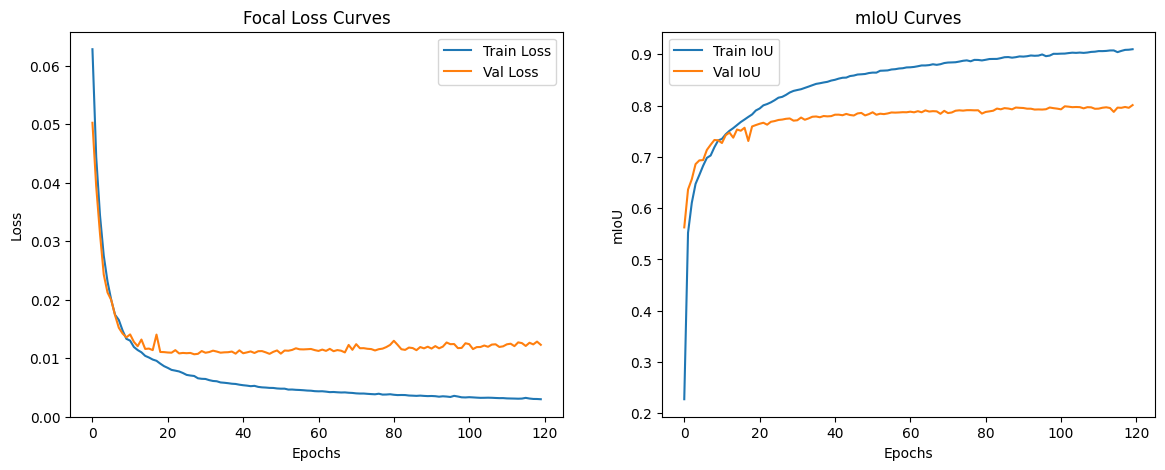

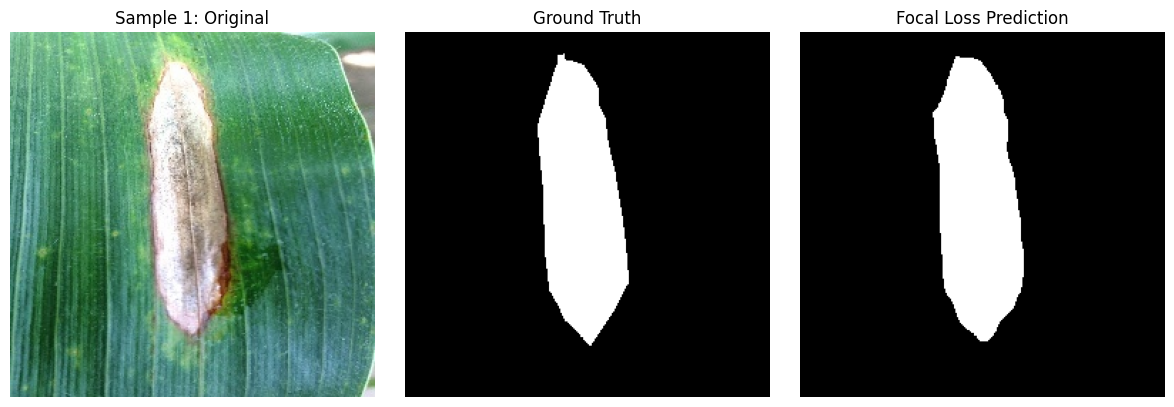

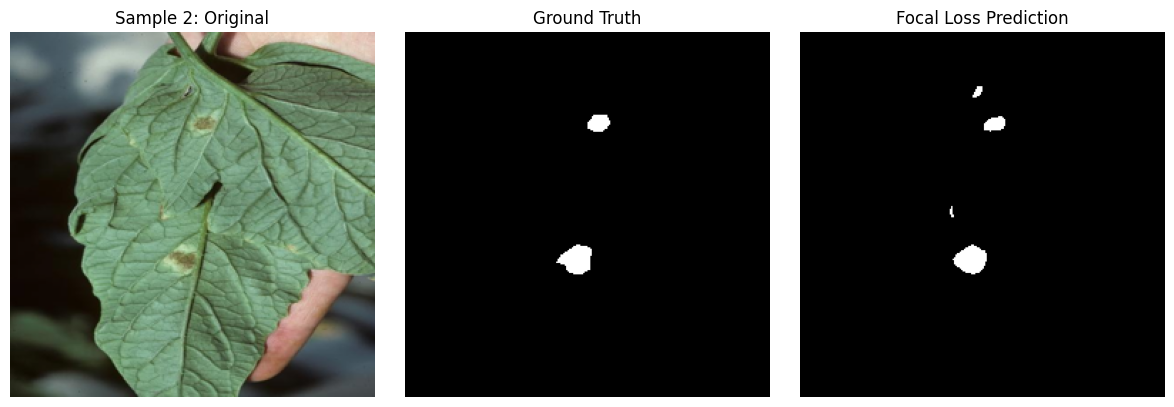

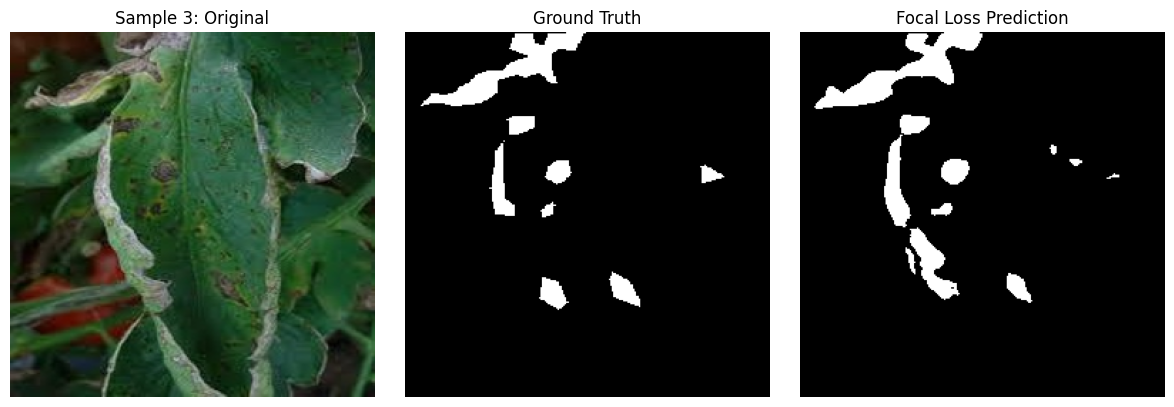

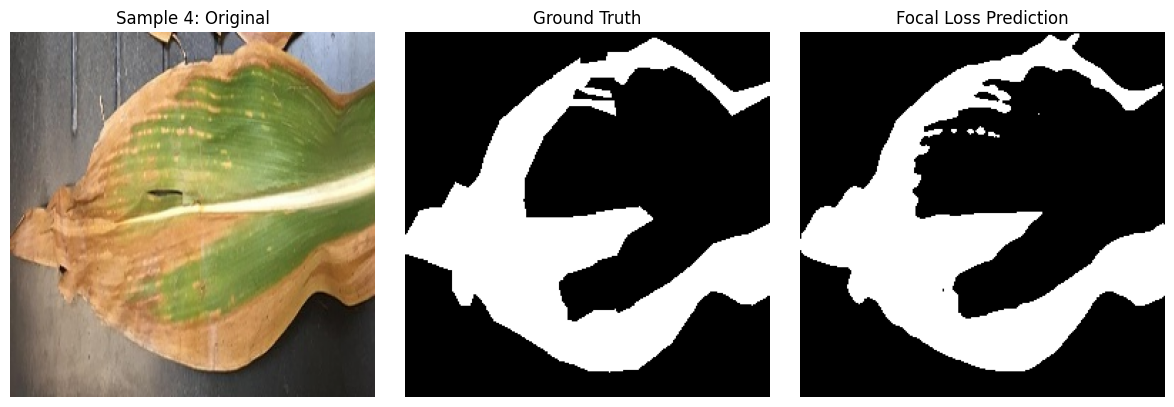

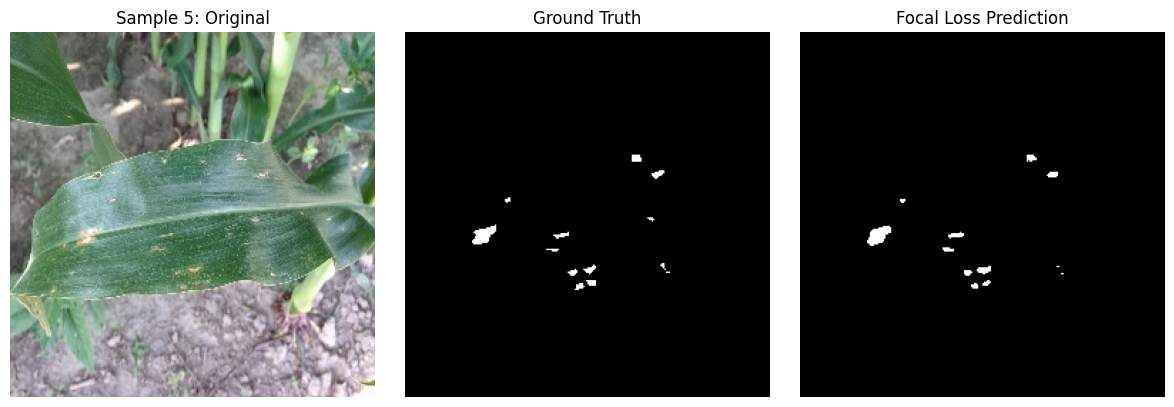

In [2]:
# --- 1. PLOT LEARNING CURVES ---
# This visually confirms if Focal Loss helped stabilize the training
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Focal Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_ious, label='Train IoU')
plt.plot(val_ious, label='Val IoU')
plt.title('mIoU Curves')
plt.xlabel('Epochs')
plt.ylabel('mIoU')
plt.legend()
plt.show()

# --- 2. FINAL VISUALIZATION ---
# Displays a few samples from the validation set to check segmentation quality
def visualize_results(model, loader, num_samples=5):
    if os.path.exists("best_model.pth"):
        model.load_state_dict(torch.load("best_model.pth"))
    model.eval()

    # Get a batch of data
    images, masks = next(iter(loader))

    with torch.no_grad():
        # Pass through model to get logits, then sigmoid to get probabilities
        outputs = model(images.to(DEVICE))
        preds = (torch.sigmoid(outputs) > 0.5).float()

    for i in range(min(num_samples, BATCH_SIZE)):
        # Denormalize image for display
        img = images[i].cpu().permute(1,2,0).numpy()
        img = np.clip(img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)

        plt.figure(figsize=(12, 4))

        # Original Image
        plt.subplot(1, 3, 1)
        plt.imshow(img)
        plt.title(f"Sample {i+1}: Original")
        plt.axis('off')

        # Ground Truth Mask
        plt.subplot(1, 3, 2)
        plt.imshow(masks[i][0], cmap='gray')
        plt.title("Ground Truth")
        plt.axis('off')

        # Model Prediction
        plt.subplot(1, 3, 3)
        plt.imshow(preds[i][0].cpu(), cmap='gray')
        plt.title("Focal Loss Prediction")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

# Execute visualization
visualize_results(model, val_loader)